# Homework 5 - Pattern Recognition and Machine Learning

**Clustering**

$k$-means partitions $n$ points into $k$ clusters by minimising the within-cluster sum of squares
(WCSS):

$$J = \sum_{j=1}^{k}\sum_{x_i \in C_j} \lVert x_i - \mu_j \rVert^2,$$

alternating between an **assignment** step (each point joins its nearest centroid) and an **update**
step (each centroid moves to the mean of its points).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

# three Gaussian clusters in R^2
true_means = np.array([[0.0, 0.0], [5.0, 5.0], [0.0, 6.0]])
n_per = 150
X = np.vstack([
    np.random.multivariate_normal(m, np.eye(2)*0.8, size=n_per)
    for m in true_means
])
y_true = np.repeat([0, 1, 2], n_per)
print("X shape:", X.shape)

X shape: (450, 2)


# 1 / Implement k-means

## a) Implement the k-means algorithm from scratch

In [ ]:
def kmeans(X, k, max_iter=100, seed=0, tol=1e-6):
    rng = np.random.default_rng(seed)
    centroids = X[rng.choice(len(X), k, replace=False)].copy() # initialise centroids at random data points
    history = []
    for it in range(max_iter):
        dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        labels = dists.argmin(axis=1)
        history.append((centroids.copy(), labels.copy()))

        new_centroids = np.array([
            X[labels == j].mean(axis=0) if np.any(labels == j) else centroids[j]
            for j in range(k)
        ])
        if np.linalg.norm(new_centroids - centroids) < tol:
            centroids = new_centroids
            break
        centroids = new_centroids
    wcss = np.sum((X - centroids[labels])**2)
    return labels, centroids, wcss, history

def compute_wcss(X, labels, centroids):
    return np.sum((X - centroids[labels])**2)

## b) Run k-means with $k = 3$

In [3]:
labels, centroids, wcss, history = kmeans(X, k=3, seed=0)
print("Final WCSS:", round(wcss, 2))
print("Iterations to converge:", len(history))
print("Centroids:\n", centroids.round(2))

Final WCSS: 699.03
Iterations to converge: 6
Centroids:
 [[-0.03  0.08]
 [ 4.86  4.87]
 [-0.08  5.9 ]]


## c) Visualise cluster assignments and centroids

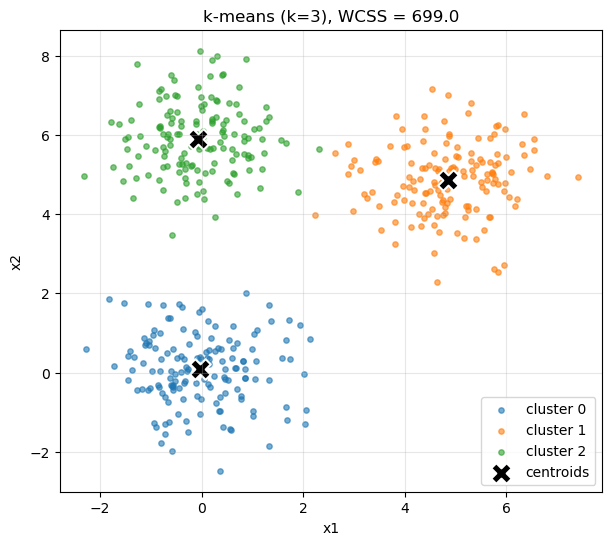

In [4]:
plt.figure(figsize=(7, 6))
for j in range(3):
    m = labels == j
    plt.scatter(X[m, 0], X[m, 1], s=15, alpha=0.6, label=f"cluster {j}")
plt.scatter(centroids[:, 0], centroids[:, 1], marker="X", s=220,
            c="black", edgecolor="white", linewidth=1.5, label="centroids")
plt.title(f"k-means (k=3), WCSS = {wcss:.1f}")
plt.xlabel("x1"); plt.ylabel("x2"); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

Snapshots of how the assignments evolve across the first iterations.

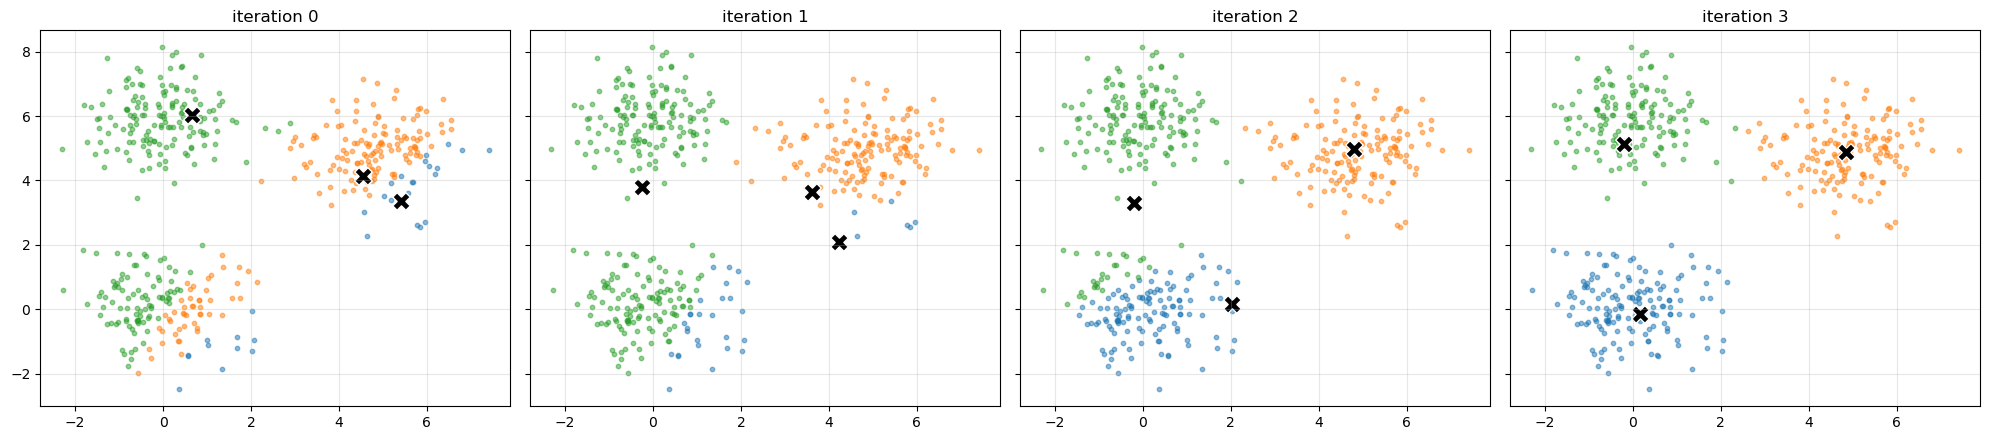

In [5]:
steps = list(range(min(4, len(history))))
fig, axes = plt.subplots(1, len(steps), figsize=(5*len(steps), 4.5), sharex=True, sharey=True)
if len(steps) == 1: axes = [axes]
for ax, it in zip(axes, steps):
    cen, lab = history[it]
    for j in range(3):
        ax.scatter(X[lab==j,0], X[lab==j,1], s=10, alpha=0.5)
    ax.scatter(cen[:,0], cen[:,1], marker="X", s=160, c="black",
               edgecolor="white")
    ax.set_title(f"iteration {it}")
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Discussion — how assignments evolve and why k-means converges

Each iteration runs two steps that can only *decrease* (never increase) the objective $J$:
the assignment step moves every point to its nearest centroid (lowering its squared distance), and the
update step moves every centroid to the mean of its members (the mean is the point minimising the sum of
squared distances). Since $J\ge 0$ and decreases monotonically, and there are only finitely many possible
assignments, the algorithm must reach a fixed point in finite time. In the snapshots the centroids start
at random points, then quickly slide toward the three Gaussian blobs and the boundaries stabilise after a
few iterations. Note this is convergence to a **local** minimum, not necessarily the global one.

# 2 / Initialization sensitivity

In [6]:
results = []
for seed in range(8):
    lab, cen, w, hist = kmeans(X, k=3, seed=seed)
    results.append((seed, w, len(hist)))
    print(f"seed {seed}: WCSS = {w:8.2f}   iters = {len(hist)}")

best = min(results, key=lambda r: r[1])
worst = max(results, key=lambda r: r[1])
print(f"\nBest WCSS  = {best[1]:.2f} (seed {best[0]})")
print(f"Worst WCSS = {worst[1]:.2f} (seed {worst[0]})")

seed 0: WCSS =   699.03   iters = 6
seed 1: WCSS =   699.03   iters = 4
seed 2: WCSS =   699.03   iters = 14
seed 3: WCSS =   699.03   iters = 5
seed 4: WCSS =   699.03   iters = 4
seed 5: WCSS =   699.03   iters = 5
seed 6: WCSS =   699.03   iters = 4
seed 7: WCSS =   699.03   iters = 4

Best WCSS  = 699.03 (seed 0)
Worst WCSS = 699.03 (seed 0)


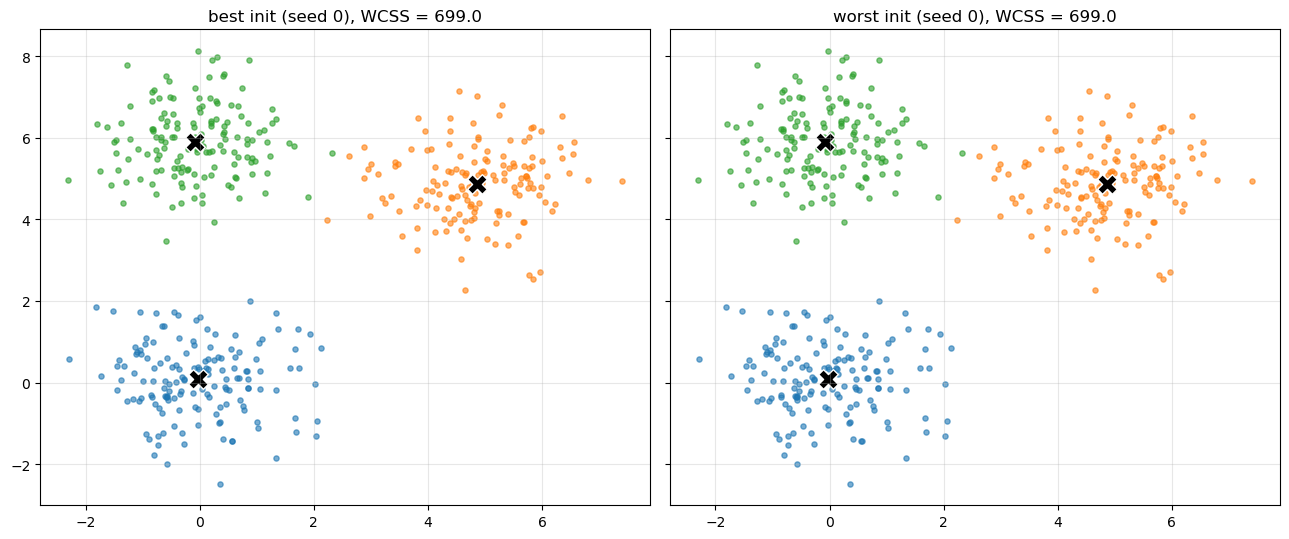

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for ax, (seed, title) in zip(axes, [(best[0], "best init"), (worst[0], "worst init")]):
    lab, cen, w, _ = kmeans(X, k=3, seed=seed)
    for j in range(3):
        ax.scatter(X[lab==j,0], X[lab==j,1], s=14, alpha=0.6)
    ax.scatter(cen[:,0], cen[:,1], marker="X", s=200, c="black", edgecolor="white")
    ax.set_title(f"{title} (seed {seed}), WCSS = {w:.1f}")
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Discussion — why initialization matters

$k$-means only guarantees a **local** optimum, and which one it reaches is fully determined by the starting
centroids. A poor initialisation — e.g. two seeds inside the same true blob — can leave one real cluster
split in half and two others merged, producing a noticeably higher WCSS that the alternating updates can
never escape (no single reassignment lowers $J$). That is why runs differ in both the final WCSS and the
number of iterations. The standard remedies are to run $k$-means many times with different seeds and keep
the lowest-WCSS solution, and to use a smarter seeding such as **k-means++**, which spreads initial
centroids out and makes good solutions far more likely.

# 3 / Choosing the number of clusters

## a) Compute WCSS for each k    ## b) Plot WCSS vs k

k = 1: WCSS = 6014.55
k = 2: WCSS = 2604.03
k = 3: WCSS = 699.03
k = 4: WCSS = 607.25
k = 5: WCSS = 524.75
k = 6: WCSS = 451.40
k = 7: WCSS = 410.15
k = 8: WCSS = 380.32


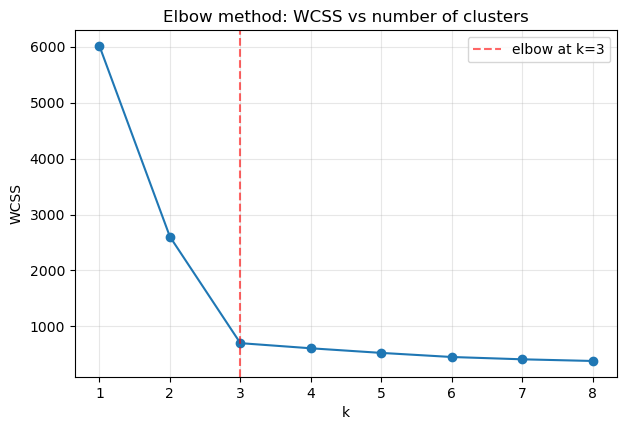

In [ ]:
ks = range(1, 9)
wcss_by_k = []
for k in ks:
    w = min(kmeans(X, k=k, seed=s)[2] for s in range(5))
    wcss_by_k.append(w)
    print(f"k = {k}: WCSS = {w:.2f}")

plt.figure(figsize=(7, 4.5))
plt.plot(list(ks), wcss_by_k, marker="o")
plt.axvline(3, color="red", linestyle="--", alpha=0.6, label="elbow at k=3")
plt.xlabel("k"); plt.ylabel("WCSS")
plt.title("Elbow method: WCSS vs number of clusters")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

### Discussion — the elbow method

WCSS decreases monotonically with $k$ (more centroids can only fit the data more tightly; at $k=n$ it hits
zero), so the minimum alone is not a useful criterion. Instead we look for the **elbow** — the $k$ after
which adding clusters yields only marginal improvement. Here WCSS drops steeply from $k=1$ to $k=3$ and
then flattens, so $k=3$ is the natural choice, matching the three Gaussian blobs we generated. Beyond the
elbow, extra clusters merely split genuine groups and add little explanatory value.

# 4 / Hierarchical clustering

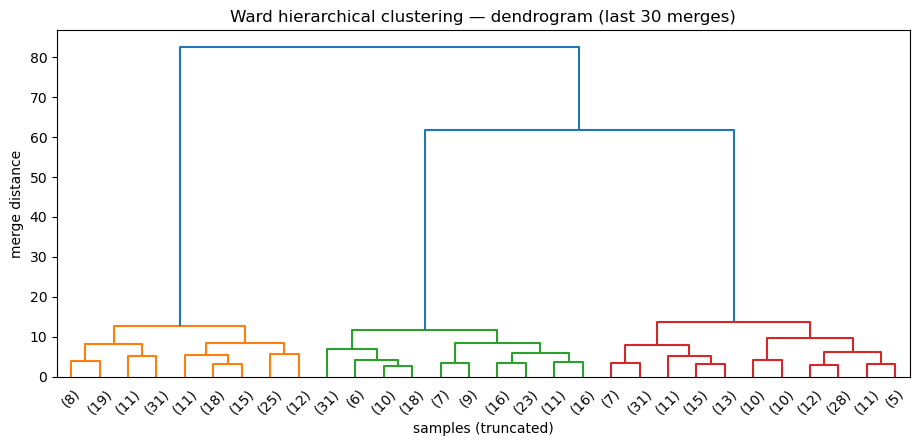

In [9]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

Z = linkage(X, method="ward")

plt.figure(figsize=(11, 4.5))
dendrogram(Z, truncate_mode="lastp", p=30, show_leaf_counts=True)
plt.title("Ward hierarchical clustering — dendrogram (last 30 merges)")
plt.xlabel("samples (truncated)"); plt.ylabel("merge distance")
plt.show()

## b) Cluster assignments for three clusters, compared with k-means

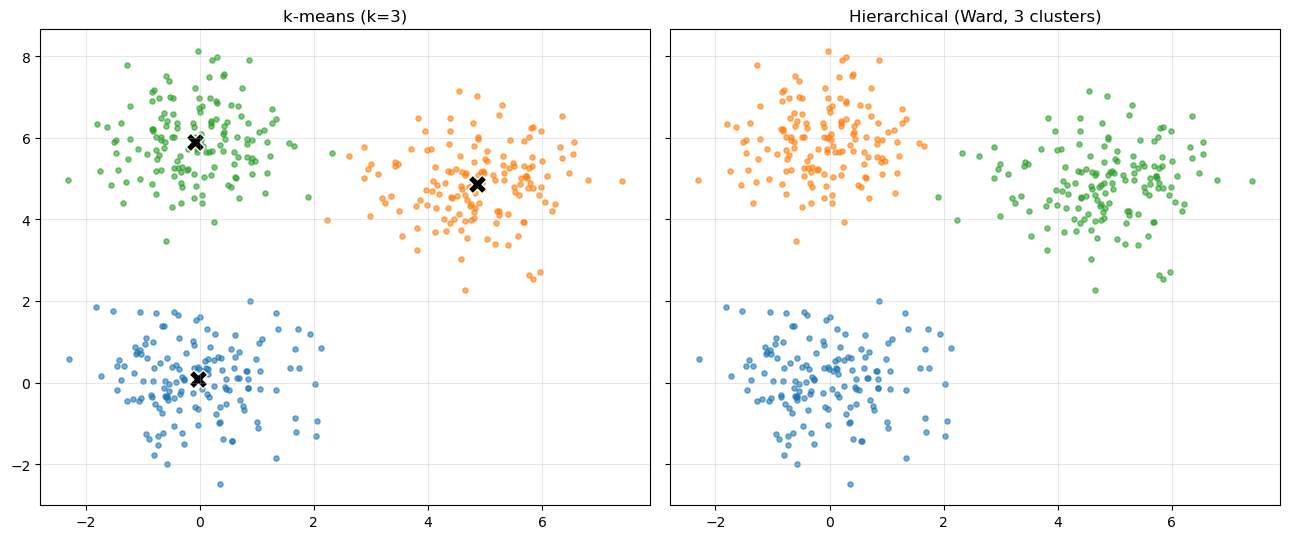

Approx. agreement with k-means: 99.56%


In [ ]:
hc_labels = fcluster(Z, t=3, criterion="maxclust")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for j in range(3):
    axes[0].scatter(X[labels==j,0], X[labels==j,1], s=14, alpha=0.6)
axes[0].scatter(centroids[:,0], centroids[:,1], marker="X", s=180, c="black", edgecolor="white")
axes[0].set_title("k-means (k=3)")
for j in np.unique(hc_labels):
    axes[1].scatter(X[hc_labels==j,0], X[hc_labels==j,1], s=14, alpha=0.6)
axes[1].set_title("Hierarchical (Ward, 3 clusters)")
for ax in axes: ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

from scipy.stats import mode
agree = 0
for j in np.unique(hc_labels):
    members = labels[hc_labels == j]
    agree += np.sum(members == mode(members, keepdims=True).mode[0])
print(f"Approx. agreement with k-means: {agree/len(X):.2%}")

### Discussion — hierarchical vs k-means

Ward linkage merges the clusters that least increase total within-cluster variance, which targets the same
compact, roughly spherical structure as $k$-means — so on these three well-separated Gaussian blobs the two
methods produce nearly identical partitions. The differences: hierarchical clustering needs **no preset
$k$** (the dendrogram shows the whole merge hierarchy and lets us cut at any level) and is deterministic,
but it is $O(n^2)$–$O(n^3)$ in memory/time and merges are greedy and irreversible. $k$-means is cheap and
scales well but needs $k$ in advance and depends on initialisation. The dendrogram's large vertical gap
before the final three-cluster merge independently confirms $k=3$.

# 5 / Failure case

A ring (two concentric circles) — clusters that are not spherical.

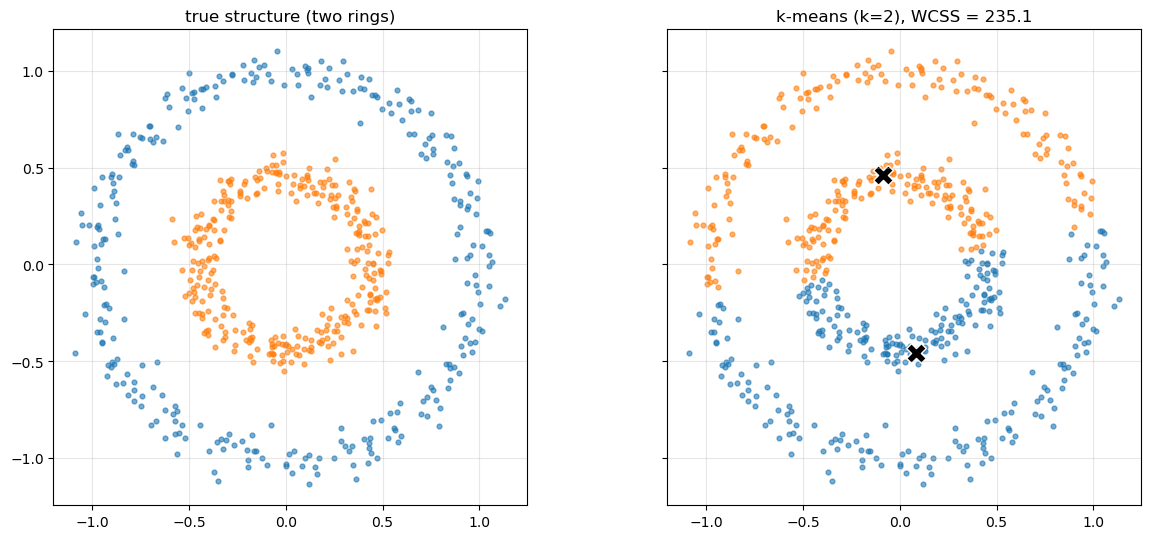

In [11]:
from sklearn.datasets import make_circles
Xr, yr = make_circles(n_samples=600, factor=0.45, noise=0.06, random_state=0)

lab_r, cen_r, w_r, _ = kmeans(Xr, k=2, seed=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for cls in [0, 1]:
    axes[0].scatter(Xr[yr==cls,0], Xr[yr==cls,1], s=12, alpha=0.6)
axes[0].set_title("true structure (two rings)")
for j in [0, 1]:
    axes[1].scatter(Xr[lab_r==j,0], Xr[lab_r==j,1], s=12, alpha=0.6)
axes[1].scatter(cen_r[:,0], cen_r[:,1], marker="X", s=200, c="black", edgecolor="white")
axes[1].set_title(f"k-means (k=2), WCSS = {w_r:.1f}")
for ax in axes: ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

/opt/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


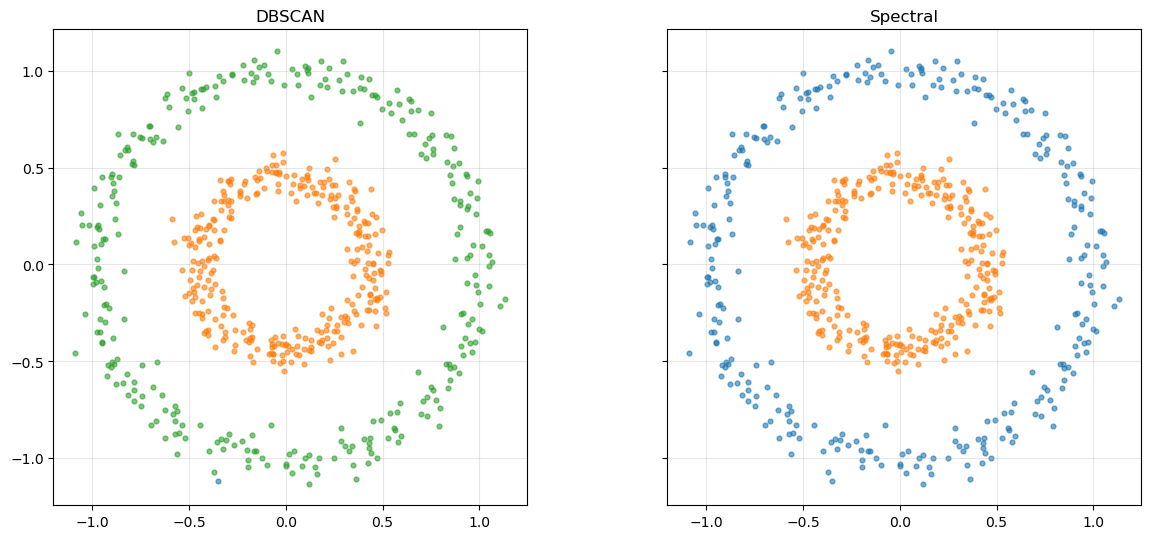

In [12]:
# a method that handles non-convex shapes: DBSCAN / spectral clustering
from sklearn.cluster import DBSCAN, SpectralClustering
db = DBSCAN(eps=0.15, min_samples=5).fit(Xr)
sp = SpectralClustering(n_clusters=2, affinity="nearest_neighbors",
                        random_state=0).fit(Xr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for ax, (name, lab) in zip(axes, [("DBSCAN", db.labels_), ("Spectral", sp.labels_)]):
    for j in np.unique(lab):
        ax.scatter(Xr[lab==j,0], Xr[lab==j,1], s=12, alpha=0.6)
    ax.set_title(f"{name}")
    ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Discussion — why k-means fails and what works better

$k$-means assigns each point to the nearest centroid, so its decision boundaries are straight lines
(a Voronoi tessellation) and every cluster is implicitly assumed **convex and roughly spherical** with
similar size. A ring violates this: the natural clusters are nested, the inner ring's points are actually
closer to the outer ring's centroid on the opposite side, so $k$-means slices the rings into two
half-moons instead of recovering them. Methods that rely on *connectivity* or *density* rather than
distance-to-centroid succeed: **DBSCAN** grows clusters through dense neighbourhoods and recovers arbitrary
shapes (also labelling noise), and **spectral clustering** embeds the data via a neighbourhood graph where
the rings become linearly separable. Gaussian mixture models help with elliptical (but still convex)
clusters, which would not be enough here.